In [5]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

import matplotlib.pyplot as plt

In [6]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

In [7]:
DATA_PATH = "../data/raw/dataset-electronics-5M.parquet"

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000
N_CLUSTERS = 10
PCA_DIM = 256

In [8]:
parquet_file = pq.ParquetFile(DATA_PATH)

print("Количество строк:", parquet_file.metadata.num_rows)
print("Количество row groups:", parquet_file.num_row_groups)

Количество строк: 4793821
Количество row groups: 2108


In [9]:
category_data = parquet_file.read(
    columns=["category_id"]
).to_pandas()

print(category_data.shape)
print("Уникальных категорий:", category_data["category_id"].nunique())

(4793821, 1)
Уникальных категорий: 122


In [10]:
sample_fraction = SAMPLE_SIZE / len(category_data)

sample_indices = (
    category_data
    .groupby("category_id", group_keys=False)
    .sample(
        frac=sample_fraction,
        random_state=RANDOM_STATE
    )
    .index
)

sample_indices = np.sort(sample_indices.to_numpy())

print("Размер выборки:", len(sample_indices))

Размер выборки: 100001


In [11]:
def decode_embedding(data):
    data = bytes(data)

    if len(data) != 3122:
        raise ValueError(
            f"Неожиданный размер embedding: {len(data)}"
        )

    values = np.empty(312, dtype=np.float64)

    for i in range(312):
        start = 2 + i * 10
        values[i] = np.frombuffer(
            data[start:start + 8],
            dtype="<f8"
        )[0]

    return values.astype(np.float32)

In [12]:
selected_embeddings = []
selected_categories = []

sample_set = set(sample_indices)

current_index = 0

for batch in parquet_file.iter_batches(
    columns=["embedding", "category_id"],
    batch_size=10_000
):
    batch_df = batch.to_pandas()

    batch_start = current_index
    batch_end = current_index + len(batch_df)

    local_indices = [
        i - batch_start
        for i in sample_indices
        if batch_start <= i < batch_end
    ]

    for i in local_indices:
        embedding = decode_embedding(
            batch_df.iloc[i]["embedding"]
        )

        selected_embeddings.append(embedding)
        selected_categories.append(
            batch_df.iloc[i]["category_id"]
        )

    current_index = batch_end

    if current_index >= sample_indices[-1]:
        break

In [13]:
X = np.asarray(
    selected_embeddings,
    dtype=np.float32
)

y = np.asarray(
    selected_categories
)

print("X:", X.shape)
print("y:", y.shape)
print("Уникальных категорий:", len(np.unique(y)))

X: (100001, 312)
y: (100001,)
Уникальных категорий: 120


In [14]:
print("dtype:", X.dtype)
print("min:", X.min())
print("max:", X.max())
print("mean:", X.mean())
print("std:", X.std())

dtype: float32
min: -0.34765625
max: 0.32421875
mean: 0.00033404317
std: 0.05662045


In [15]:
RANDOM_STATE = 42

N_CLUSTERS = 10
PCA_DIM = 256

Почему K=10?

Потому что в нашем предыдущем эксперименте именно K=10 показал лучший баланс:

* Silhouette = 0.0907
* ARI = 0.3978
* NMI = 0.5005

Поэтому для первой итерации DeepCluster логично начать с него.

In [16]:
print("X:", X.shape)
print("y:", y.shape)
print("Уникальных категорий:", len(np.unique(y)))

X: (100001, 312)
y: (100001,)
Уникальных категорий: 120


In [17]:
pca = PCA(
    n_components=PCA_DIM,
    whiten=True,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X)

print("Исходная размерность:", X.shape[1])
print("Размерность после PCA:", X_pca.shape[1])
print(
    "Объяснённая дисперсия:",
    pca.explained_variance_ratio_.sum()
)

Исходная размерность: 312
Размерность после PCA: 256
Объяснённая дисперсия: 0.99869895


In [18]:
X_cluster = normalize(X_pca, norm="l2")

print("Shape:", X_cluster.shape)

norms = np.linalg.norm(X_cluster, axis=1)

print("Минимальная норма:", norms.min())
print("Максимальная норма:", norms.max())
print("Средняя норма:", norms.mean())

Shape: (100001, 256)
Минимальная норма: 0.9999998
Максимальная норма: 1.0000002
Средняя норма: 1.0


In [19]:
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

pseudo_labels = kmeans.fit_predict(X_cluster)

In [20]:
print("Количество кластеров:", len(np.unique(pseudo_labels)))

cluster_sizes = pd.Series(pseudo_labels).value_counts().sort_index()

print(cluster_sizes)

Количество кластеров: 10
0    43158
1     9811
2      552
3     3215
4     5260
5     8597
6    14676
7     1463
8     5004
9     8265
Name: count, dtype: int64


In [21]:
print("Минимальный размер кластера:", cluster_sizes.min())
print("Максимальный размер кластера:", cluster_sizes.max())
print("Средний размер:", cluster_sizes.mean())
print("Медианный размер:", cluster_sizes.median())

Минимальный размер кластера: 552
Максимальный размер кластера: 43158
Средний размер: 10000.1
Медианный размер: 6762.5


In [22]:
cluster_sizes.describe()

count       10.000000
mean     10000.100000
std      12391.489951
min        552.000000
25%       3662.250000
50%       6762.500000
75%       9507.500000
max      43158.000000
Name: count, dtype: float64

In [23]:
print("\nСтатистика размеров кластеров:")
print(cluster_sizes.describe())

print("\nМинимальный кластер:", cluster_sizes.min())
print("Максимальный кластер:", cluster_sizes.max())
print("Средний кластер:", cluster_sizes.mean())


Статистика размеров кластеров:
count       10.000000
mean     10000.100000
std      12391.489951
min        552.000000
25%       3662.250000
50%       6762.500000
75%       9507.500000
max      43158.000000
Name: count, dtype: float64

Минимальный кластер: 552
Максимальный кластер: 43158
Средний кластер: 10000.1


In [24]:
silhouette = silhouette_score(
    X_cluster,
    pseudo_labels,
    sample_size=20_000,
    random_state=RANDOM_STATE
)

ari = adjusted_rand_score(y, pseudo_labels)
nmi = normalized_mutual_info_score(y, pseudo_labels)

print(f"Silhouette: {silhouette:.6f}")
print(f"ARI:        {ari:.6f}")
print(f"NMI:        {nmi:.6f}")

Silhouette: 0.007395
ARI:        0.095235
NMI:        0.386892


In [25]:
article_baseline = {
    "iteration": 0,
    "n_clusters": N_CLUSTERS,
    "silhouette": silhouette,
    "ARI": ari,
    "NMI": nmi
}

article_baseline

{'iteration': 0,
 'n_clusters': 10,
 'silhouette': 0.0073948753997683525,
 'ARI': 0.09523530481678096,
 'NMI': 0.3868921565079006}

In [26]:
import torch

print(torch.__version__)
print(torch.__file__)

2.13.0
/Users/denis/Desktop/coursework/Course_work_community_detection/.venv/lib/python3.13/site-packages/torch/__init__.py


In [27]:
import torch

MODEL_PATH = "../models/epoch_64_encoder.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

print("Тип checkpoint:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nКлючи checkpoint:")
    for key in checkpoint.keys():
        print(" -", key)

    print("\nКоличество элементов:", len(checkpoint))

Тип checkpoint: <class 'dict'>

Ключи checkpoint:
 - meta
 - state_dict
 - optimizer
 - scheduler

Количество элементов: 4


In [28]:
print("META:")
for key, value in checkpoint["meta"].items():
    print(f"{key}: {value}")
    

META:
epoch: 64
iter: 6400
time: Mon Sep  8 11:22:19 2025


In [29]:
print("\nSTATE_DICT:")

for key, value in checkpoint["state_dict"].items():
    print(f"{key:70s} {tuple(value.shape)}")
    


STATE_DICT:
embeddings.word_embeddings.weight                                      (83828, 312)
embeddings.position_embeddings.weight                                  (2048, 312)
embeddings.token_type_embeddings.weight                                (2, 312)
embeddings.LayerNorm.weight                                            (312,)
embeddings.LayerNorm.bias                                              (312,)
encoder.layer.0.attention.self.query.weight                            (312, 312)
encoder.layer.0.attention.self.query.bias                              (312,)
encoder.layer.0.attention.self.key.weight                              (312, 312)
encoder.layer.0.attention.self.key.bias                                (312,)
encoder.layer.0.attention.self.value.weight                            (312, 312)
encoder.layer.0.attention.self.value.bias                              (312,)
encoder.layer.0.attention.output.dense.weight                          (312, 312)
encoder.layer.0.attent

In [30]:
print("STATE_DICT:")

for key, value in checkpoint["state_dict"].items():
    print(f"{key:70s} {tuple(value.shape)}")

STATE_DICT:
embeddings.word_embeddings.weight                                      (83828, 312)
embeddings.position_embeddings.weight                                  (2048, 312)
embeddings.token_type_embeddings.weight                                (2, 312)
embeddings.LayerNorm.weight                                            (312,)
embeddings.LayerNorm.bias                                              (312,)
encoder.layer.0.attention.self.query.weight                            (312, 312)
encoder.layer.0.attention.self.query.bias                              (312,)
encoder.layer.0.attention.self.key.weight                              (312, 312)
encoder.layer.0.attention.self.key.bias                                (312,)
encoder.layer.0.attention.self.value.weight                            (312, 312)
encoder.layer.0.attention.self.value.bias                              (312,)
encoder.layer.0.attention.output.dense.weight                          (312, 312)
encoder.layer.0.attenti

In [31]:
state_dict = checkpoint["state_dict"]

# Количество Transformer-слоёв
layer_ids = set()

for key in state_dict.keys():
    if key.startswith("encoder.layer."):
        layer_id = key.split(".")[2]
        layer_ids.add(int(layer_id))

print("Количество Transformer-слоёв:", len(layer_ids))
print("Номера слоёв:", sorted(layer_ids))

# Размерности основных компонентов
print("\nРазмерности:")
print("Vocabulary:", state_dict["embeddings.word_embeddings.weight"].shape[0])
print("Hidden size:", state_dict["embeddings.word_embeddings.weight"].shape[1])
print("Max position:", state_dict["embeddings.position_embeddings.weight"].shape[0])
print("Intermediate size:", state_dict["encoder.layer.0.intermediate.dense.weight"].shape[0])

# Смотрим последние ключи state_dict
print("\nПоследние 20 ключей:")
for key in list(state_dict.keys())[-20:]:
    print(key, tuple(state_dict[key].shape))

Количество Transformer-слоёв: 3
Номера слоёв: [0, 1, 2]

Размерности:
Vocabulary: 83828
Hidden size: 312
Max position: 2048
Intermediate size: 600

Последние 20 ключей:
encoder.layer.1.output.dense.weight (312, 600)
encoder.layer.1.output.dense.bias (312,)
encoder.layer.1.output.LayerNorm.weight (312,)
encoder.layer.1.output.LayerNorm.bias (312,)
encoder.layer.2.attention.self.query.weight (312, 312)
encoder.layer.2.attention.self.query.bias (312,)
encoder.layer.2.attention.self.key.weight (312, 312)
encoder.layer.2.attention.self.key.bias (312,)
encoder.layer.2.attention.self.value.weight (312, 312)
encoder.layer.2.attention.self.value.bias (312,)
encoder.layer.2.attention.output.dense.weight (312, 312)
encoder.layer.2.attention.output.dense.bias (312,)
encoder.layer.2.attention.output.LayerNorm.weight (312,)
encoder.layer.2.attention.output.LayerNorm.bias (312,)
encoder.layer.2.intermediate.dense.weight (600, 312)
encoder.layer.2.intermediate.dense.bias (600,)
encoder.layer.2.output.

In [32]:
print("Все ключи state_dict:\n")

for key in state_dict.keys():
    print(key)

Все ключи state_dict:

embeddings.word_embeddings.weight
embeddings.position_embeddings.weight
embeddings.token_type_embeddings.weight
embeddings.LayerNorm.weight
embeddings.LayerNorm.bias
encoder.layer.0.attention.self.query.weight
encoder.layer.0.attention.self.query.bias
encoder.layer.0.attention.self.key.weight
encoder.layer.0.attention.self.key.bias
encoder.layer.0.attention.self.value.weight
encoder.layer.0.attention.self.value.bias
encoder.layer.0.attention.output.dense.weight
encoder.layer.0.attention.output.dense.bias
encoder.layer.0.attention.output.LayerNorm.weight
encoder.layer.0.attention.output.LayerNorm.bias
encoder.layer.0.intermediate.dense.weight
encoder.layer.0.intermediate.dense.bias
encoder.layer.0.output.dense.weight
encoder.layer.0.output.dense.bias
encoder.layer.0.output.LayerNorm.weight
encoder.layer.0.output.LayerNorm.bias
encoder.layer.1.attention.self.query.weight
encoder.layer.1.attention.self.query.bias
encoder.layer.1.attention.self.key.weight
encoder.lay

In [33]:
print("META:")
print(checkpoint["meta"])

print("\nOptimizer keys:")
print(checkpoint["optimizer"].keys())

print("\nScheduler keys:")
print(checkpoint["scheduler"].keys())

META:
{'epoch': 64, 'iter': 6400, 'time': 'Mon Sep  8 11:22:19 2025'}

Optimizer keys:
dict_keys(['state', 'param_groups'])

Scheduler keys:
dict_keys(['T_max', 'eta_min', 'base_lrs', 'last_epoch', 'verbose', '_step_count', '_get_lr_called_within_step', '_last_lr'])


In [34]:
import torch

state_dict = checkpoint["state_dict"]

print("Количество параметров:")

total_params = sum(
    tensor.numel()
    for tensor in state_dict.values()
)

print(f"{total_params:,}")
print(f"{total_params / 1e6:.2f} млн")

Количество параметров:
29,096,112
29.10 млн


In [35]:
print("Тип meta:", type(checkpoint["meta"]))

for key, value in checkpoint["meta"].items():
    print(f"{key}: {value!r}")

Тип meta: <class 'dict'>
epoch: 64
iter: 6400
time: 'Mon Sep  8 11:22:19 2025'


In [36]:
import torch

MODEL_PATH = "../models/epoch_64_encoder.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

state_dict = checkpoint["state_dict"]

print("Checkpoint загружен")

Checkpoint загружен


In [37]:
print("Количество параметров:", f"{total_params:,}")

Количество параметров: 29,096,112


In [38]:
hidden_size = state_dict["embeddings.word_embeddings.weight"].shape[1]
vocab_size = state_dict["embeddings.word_embeddings.weight"].shape[0]
max_position_embeddings = state_dict["embeddings.position_embeddings.weight"].shape[0]

num_hidden_layers = len({
    int(key.split(".")[2])
    for key in state_dict
    if key.startswith("encoder.layer.")
})

intermediate_size = state_dict[
    "encoder.layer.0.intermediate.dense.weight"
].shape[0]

print("Архитектура checkpoint:")
print("vocab_size:", vocab_size)
print("hidden_size:", hidden_size)
print("max_position_embeddings:", max_position_embeddings)
print("num_hidden_layers:", num_hidden_layers)
print("intermediate_size:", intermediate_size)

Архитектура checkpoint:
vocab_size: 83828
hidden_size: 312
max_position_embeddings: 2048
num_hidden_layers: 3
intermediate_size: 600


In [39]:
from pathlib import Path

cache_dir = Path.home() / ".cache" / "huggingface" / "hub"

print("Hugging Face cache:")
print(cache_dir)
print("Существует:", cache_dir.exists())

if cache_dir.exists():
    for path in cache_dir.glob("*rubert*"):
        print(path)

Hugging Face cache:
/Users/denis/.cache/huggingface/hub
Существует: True
/Users/denis/.cache/huggingface/hub/models--cointegrated--rubert-tiny2


In [40]:
from pathlib import Path

model_cache = Path.home() / ".cache" / "huggingface" / "hub" / "models--cointegrated--rubert-tiny2"

for path in model_cache.rglob("*"):
    if path.is_file():
        print(path)

/Users/denis/.cache/huggingface/hub/models--cointegrated--rubert-tiny2/blobs/26aa82492df46244bd53d5a520aa1d364d8d7966
/Users/denis/.cache/huggingface/hub/models--cointegrated--rubert-tiny2/refs/main
/Users/denis/.cache/huggingface/hub/models--cointegrated--rubert-tiny2/snapshots/e8ed3b0c8bbf4fb6984c3de043bf7d2f4e5969ae/config.json


In [41]:
import json

CONFIG_PATH = (
    Path.home()
    / ".cache"
    / "huggingface"
    / "hub"
    / "models--cointegrated--rubert-tiny2"
    / "snapshots"
    / "e8ed3b0c8bbf4fb6984c3de043bf7d2f4e5969ae"
    / "config.json"
)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

print(json.dumps(config, indent=2, ensure_ascii=False))

{
  "_name_or_path": "cointegrated/rubert-tiny2",
  "architectures": [
    "BertForPreTraining"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "emb_size": 312,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 312,
  "initializer_range": 0.02,
  "intermediate_size": 600,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 2048,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 3,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.12.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 83828
}


In [42]:
print("Основные параметры rubert-tiny2:")

for key in [
    "vocab_size",
    "hidden_size",
    "num_hidden_layers",
    "num_attention_heads",
    "intermediate_size",
    "max_position_embeddings",
    "hidden_act",
    "hidden_dropout_prob",
    "attention_probs_dropout_prob",
    "layer_norm_eps"
]:
    print(f"{key}: {config.get(key)}")

Основные параметры rubert-tiny2:
vocab_size: 83828
hidden_size: 312
num_hidden_layers: 3
num_attention_heads: 12
intermediate_size: 600
max_position_embeddings: 2048
hidden_act: gelu
hidden_dropout_prob: 0.1
attention_probs_dropout_prob: 0.1
layer_norm_eps: 1e-12


In [43]:
import torch
import time

print("Torch:", torch.__version__)
print("Python:", __import__("sys").version)

t = time.time()

x = torch.randn(1000, 312)
y = torch.nn.Linear(312, 312)(x)

print("Простой PyTorch работает за:", time.time() - t, "сек")

Torch: 2.13.0
Python: 3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]
Простой PyTorch работает за: 0.014141082763671875 сек


In [44]:
from pathlib import Path

model_cache = (
    Path.home()
    / ".cache"
    / "huggingface"
    / "hub"
    / "models--cointegrated--rubert-tiny2"
)

print("Файлы snapshot:")

for path in (model_cache / "snapshots").rglob("*"):
    if path.is_file():
        print(path.name, "→", path)

Файлы snapshot:
config.json → /Users/denis/.cache/huggingface/hub/models--cointegrated--rubert-tiny2/snapshots/e8ed3b0c8bbf4fb6984c3de043bf7d2f4e5969ae/config.json


In [45]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

tokenizer_files = []

for pattern in [
    "tokenizer.json",
    "tokenizer_config.json",
    "vocab.txt",
    "special_tokens_map.json",
    "*.model",
]:
    tokenizer_files.extend(PROJECT_ROOT.rglob(pattern))

print("Найдено файлов:", len(tokenizer_files))

for path in tokenizer_files:
    print(path)

Найдено файлов: 3
/Users/denis/Desktop/coursework/Course_work_community_detection/models/rubert-tiny2-tokenizer/tokenizer_config.json
/Users/denis/Desktop/coursework/Course_work_community_detection/models/rubert-tiny2-tokenizer/vocab.txt
/Users/denis/Desktop/coursework/Course_work_community_detection/models/rubert-tiny2-tokenizer/special_tokens_map.json


In [46]:
import requests
import time

url = "https://huggingface.co/cointegrated/rubert-tiny2/raw/main/tokenizer_config.json"

t = time.time()

try:
    response = requests.get(url, timeout=10)

    print("HTTP:", response.status_code)
    print("Время:", round(time.time() - t, 2), "сек")
    print("Размер:", len(response.content), "байт")

except Exception as e:
    print("Ошибка:", repr(e))
    print("Время:", round(time.time() - t, 2), "сек")

HTTP: 200
Время: 0.5 сек
Размер: 401 байт


In [47]:
from pathlib import Path
import requests

TOKENIZER_DIR = Path("../models/rubert-tiny2-tokenizer")
TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://huggingface.co/cointegrated/rubert-tiny2/resolve/main/"

files = [
    "tokenizer_config.json",
    "special_tokens_map.json",
    "vocab.txt",
]

for filename in files:
    url = BASE_URL + filename

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    path = TOKENIZER_DIR / filename
    path.write_bytes(response.content)

    print(f"{filename}: {len(response.content):,} bytes")

print("\nГотово:", TOKENIZER_DIR.resolve())

tokenizer_config.json: 401 bytes
special_tokens_map.json: 112 bytes
vocab.txt: 1,080,667 bytes

Готово: /Users/denis/Desktop/coursework/Course_work_community_detection/models/rubert-tiny2-tokenizer


In [48]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(
    TOKENIZER_DIR,
    local_files_only=True
)

print("Tokenizer загружен")
print("Размер словаря:", len(tokenizer))

Tokenizer загружен
Размер словаря: 83828


In [49]:
text = "Смартфон Apple iPhone 15 128GB"

encoded = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=2048
)

print("input_ids:", encoded["input_ids"].shape)
print("attention_mask:", encoded["attention_mask"].shape)
print("Токены:")
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]))

input_ids: torch.Size([1, 9])
attention_mask: torch.Size([1, 9])
Токены:
['[CLS]', 'Смарт', '##фон', 'Apple', 'iPhone', '15', '128', '##GB', '[SEP]']


In [50]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


X_cluster = to_numpy(X_cluster)
pseudo_labels = to_numpy(pseudo_labels)
y = to_numpy(y)

print("X_cluster:", type(X_cluster), X_cluster.shape)
print("pseudo_labels:", type(pseudo_labels), pseudo_labels.shape)
print("y:", type(y), y.shape)

X_cluster: <class 'numpy.ndarray'> (100001, 256)
pseudo_labels: <class 'numpy.ndarray'> (100001,)
y: <class 'numpy.ndarray'> (1000, 312)


In [51]:
print("X_cluster:", X_cluster.shape)
print("pseudo_labels:", pseudo_labels.shape)
print("y сейчас:", y.shape)

X_cluster: (100001, 256)
pseudo_labels: (100001,)
y сейчас: (1000, 312)


In [52]:
# Загружаем category_id из исходного Parquet
category_data = pd.read_parquet(
    DATA_PATH,
    columns=["category_id"]
)

# Восстанавливаем тот же стратифицированный sample
sample_fraction = SAMPLE_SIZE / len(category_data)

sample_indices = (
    category_data
    .groupby("category_id", group_keys=False)
    .sample(
        frac=sample_fraction,
        random_state=RANDOM_STATE
    )
    .index
)

sample_indices = np.sort(sample_indices.to_numpy())

# Берём category_id для тех же объектов
y = category_data.loc[sample_indices, "category_id"].to_numpy()

# На всякий случай приводим длины
n = min(len(y), len(X_cluster))

y = y[:n]
X_cluster = X_cluster[:n]
pseudo_labels = pseudo_labels[:n]

print("X_cluster:", X_cluster.shape)
print("pseudo_labels:", pseudo_labels.shape)
print("y:", y.shape)
print("Уникальных категорий:", len(np.unique(y)))

X_cluster: (100001, 256)
pseudo_labels: (100001,)
y: (100001,)
Уникальных категорий: 120


In [53]:
category_data = pd.read_parquet(
    DATA_PATH,
    columns=["category_id"]
)

# Ровно 100000 объектов, пропорционально размеру категорий
rng = np.random.default_rng(RANDOM_STATE)

categories = category_data["category_id"].unique()

samples_per_category = (
    category_data["category_id"]
    .value_counts(normalize=True)
    * SAMPLE_SIZE
)

sample_indices = []

for category_id in categories:
    category_indices = category_data.index[
        category_data["category_id"] == category_id
    ].to_numpy()

    n = max(1, round(samples_per_category[category_id]))

    n = min(n, len(category_indices))

    selected = rng.choice(
        category_indices,
        size=n,
        replace=False
    )

    sample_indices.extend(selected)

# Если получилось не ровно 100000 — корректируем
sample_indices = np.array(sample_indices)

if len(sample_indices) > SAMPLE_SIZE:
    sample_indices = rng.choice(
        sample_indices,
        size=SAMPLE_SIZE,
        replace=False
    )

elif len(sample_indices) < SAMPLE_SIZE:
    remaining = np.setdiff1d(
        category_data.index.to_numpy(),
        sample_indices
    )

    extra = rng.choice(
        remaining,
        size=SAMPLE_SIZE - len(sample_indices),
        replace=False
    )

    sample_indices = np.concatenate([
        sample_indices,
        extra
    ])

sample_indices = np.sort(sample_indices)

y = category_data.loc[
    sample_indices,
    "category_id"
].to_numpy()

print("Размер sample:", len(sample_indices))
print("y:", y.shape)
print("Уникальных категорий:", len(np.unique(y)))

Размер sample: 100000
y: (100000,)
Уникальных категорий: 122


In [54]:
selected_embeddings = []

sample_indices_set = set(sample_indices)

current_position = 0

for batch in parquet_file.iter_batches(
    columns=["embedding"],
    batch_size=10_000
):
    batch_size = len(batch["embedding"])

    batch_indices = np.arange(
        current_position,
        current_position + batch_size
    )

    mask = np.isin(batch_indices, sample_indices)

    if mask.any():
        selected_positions = np.where(mask)[0]

        for pos in selected_positions:
            selected_embeddings.append(
                decode_embedding(batch["embedding"][pos].as_py())
            )

    current_position += batch_size

    if current_position % 500_000 == 0:
        print(f"Обработано строк: {current_position:,}")

X = np.asarray(selected_embeddings, dtype=np.float32)

print("\nX:", X.shape)
print("y:", y.shape)
print("Размерность embedding:", X.shape[1])

Обработано строк: 500,000
Обработано строк: 1,000,000
Обработано строк: 1,500,000
Обработано строк: 2,000,000
Обработано строк: 2,500,000
Обработано строк: 3,000,000
Обработано строк: 3,500,000
Обработано строк: 4,000,000
Обработано строк: 4,500,000

X: (100000, 312)
y: (100000,)
Размерность embedding: 312


Теперь делаем Iteration 0 по методике DeepCluster: PCA → whitening → L2-нормализация → K-Means. В статье именно такая предобработка признаков используется перед K-Means.

In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

PCA_DIM = 256

pca = PCA(
    n_components=PCA_DIM,
    whiten=True,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X)

X_cluster = normalize(
    X_pca,
    norm="l2"
)

print("Исходные embeddings:", X.shape)
print("После PCA:", X_pca.shape)
print("После L2:", X_cluster.shape)

print(
    "Норма первого вектора:",
    np.linalg.norm(X_cluster[0])
)

Исходные embeddings: (100000, 312)
После PCA: (100000, 256)
После L2: (100000, 256)
Норма первого вектора: 1.0


In [56]:
from sklearn.cluster import KMeans

N_CLUSTERS = 10

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

pseudo_labels = kmeans.fit_predict(X_cluster)

print("K-Means завершён")
print("Количество кластеров:", len(np.unique(pseudo_labels)))
print("Количество объектов:", len(pseudo_labels))

K-Means завершён
Количество кластеров: 10
Количество объектов: 100000


In [57]:
cluster_counts = (
    pd.Series(pseudo_labels)
    .value_counts()
    .sort_index()
)

print("Размеры кластеров:")
print(cluster_counts)

print("\nМинимальный размер:", cluster_counts.min())
print("Максимальный размер:", cluster_counts.max())
print("Средний размер:", cluster_counts.mean())
print("Медианный размер:", cluster_counts.median())
print(
    "Отношение max/min:",
    round(cluster_counts.max() / cluster_counts.min(), 2)
)

Размеры кластеров:
0     3220
1    11526
2     1422
3    10834
4      556
5     4351
6     5364
7    10588
8    17111
9    35028
Name: count, dtype: int64

Минимальный размер: 556
Максимальный размер: 35028
Средний размер: 10000.0
Медианный размер: 7976.0
Отношение max/min: 63.0


То есть K-Means действительно сформировал сильно несбалансированные псевдоклассы. Это как раз тот случай, для которого в DeepCluster вводится балансировка при обучении на псевдометках.

Теперь нам нужно не обучать BERT, а сначала проверить, как выглядит baseline по качеству.

In [58]:
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

print("Считаем Silhouette...")
silhouette = silhouette_score(X_cluster, pseudo_labels)

print("Считаем ARI...")
ari = adjusted_rand_score(y, pseudo_labels)

print("Считаем NMI...")
nmi = normalized_mutual_info_score(y, pseudo_labels)

print("\nDeepCluster — Iteration 0")
print(f"Silhouette: {silhouette:.6f}")
print(f"ARI:        {ari:.6f}")
print(f"NMI:        {nmi:.6f}")

Считаем Silhouette...
Считаем ARI...
Считаем NMI...

DeepCluster — Iteration 0
Silhouette: 0.008472
ARI:        0.166878
NMI:        0.430607


In [59]:
kmeans_raw = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

labels_raw = kmeans_raw.fit_predict(X)

print("K-Means на исходных embeddings завершён")

print("\nСчитаем Silhouette...")
silhouette_raw = silhouette_score(X, labels_raw)

print("Считаем ARI...")
ari_raw = adjusted_rand_score(y, labels_raw)

print("Считаем NMI...")
nmi_raw = normalized_mutual_info_score(y, labels_raw)

print("\nОбычный K-Means")
print(f"Silhouette: {silhouette_raw:.6f}")
print(f"ARI:        {ari_raw:.6f}")
print(f"NMI:        {nmi_raw:.6f}")

K-Means на исходных embeddings завершён

Считаем Silhouette...
Считаем ARI...
Считаем NMI...

Обычный K-Means
Silhouette: 0.049098
ARI:        0.383857
NMI:        0.496357


In [60]:
X_l2 = normalize(
    X,
    norm="l2"
)

kmeans_l2 = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

labels_l2 = kmeans_l2.fit_predict(X_l2)

print("K-Means на L2-normalized embeddings завершён")

print("\nСчитаем Silhouette...")
silhouette_l2 = silhouette_score(X_l2, labels_l2)

print("Считаем ARI...")
ari_l2 = adjusted_rand_score(y, labels_l2)

print("Считаем NMI...")
nmi_l2 = normalized_mutual_info_score(y, labels_l2)

print("\nK-Means + L2")
print(f"Silhouette: {silhouette_l2:.6f}")
print(f"ARI:        {ari_l2:.6f}")
print(f"NMI:        {nmi_l2:.6f}")

K-Means на L2-normalized embeddings завершён

Считаем Silhouette...
Считаем ARI...
Считаем NMI...

K-Means + L2
Silhouette: 0.049064
ARI:        0.455627
NMI:        0.538521


X_2d: (20000, 2)


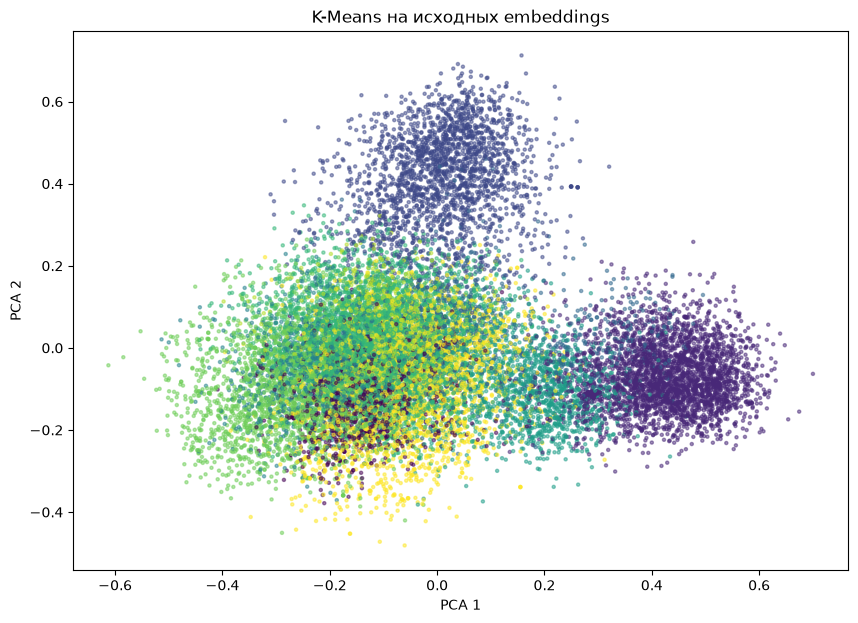

In [61]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Берём 20k объектов для визуализации
VIS_SIZE = 20_000

rng = np.random.default_rng(RANDOM_STATE)
vis_idx = rng.choice(
    len(X),
    size=VIS_SIZE,
    replace=False
)

X_vis = X[vis_idx]
labels_vis = labels_raw[vis_idx]

# PCA → 2D
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_2d = pca_2d.fit_transform(X_vis)

print("X_2d:", X_2d.shape)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_vis,
    s=5,
    alpha=0.5
)

plt.title("K-Means на исходных embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

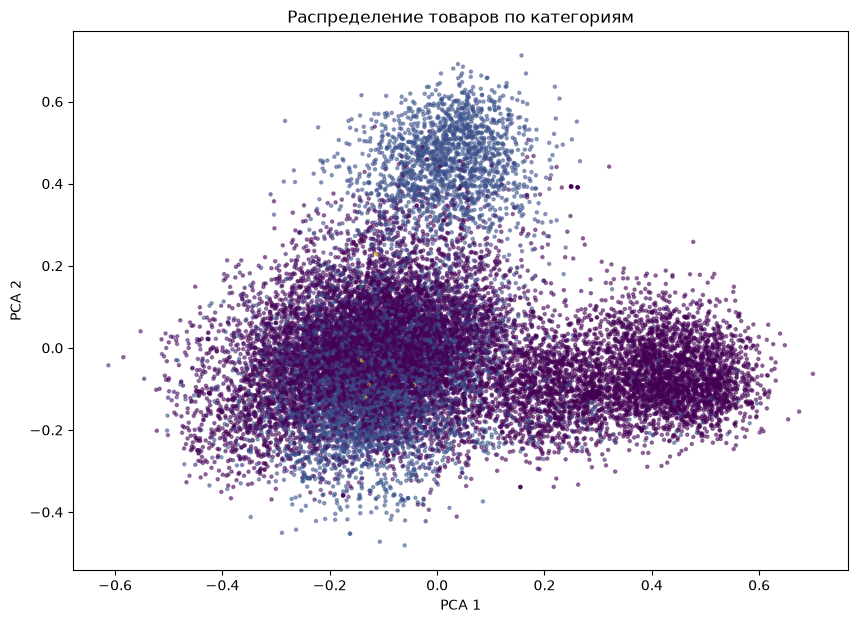

In [62]:
y_vis = y[vis_idx]

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_vis,
    s=5,
    alpha=0.5
)

plt.title("Распределение товаров по категориям")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [63]:
SAMPLE_SIZE_LARGE = 500_000

In [64]:
rng = np.random.default_rng(RANDOM_STATE)

categories = category_data["category_id"].unique()

samples_per_category = (
    category_data["category_id"]
    .value_counts(normalize=True)
    * SAMPLE_SIZE_LARGE
)

sample_indices_large = []

for category_id in categories:
    category_indices = category_data.index[
        category_data["category_id"] == category_id
    ].to_numpy()

    n = max(
        1,
        round(samples_per_category[category_id])
    )

    n = min(n, len(category_indices))

    selected = rng.choice(
        category_indices,
        size=n,
        replace=False
    )

    sample_indices_large.extend(selected)

sample_indices_large = np.asarray(
    sample_indices_large
)

# Корректируем до ровно 500k
if len(sample_indices_large) > SAMPLE_SIZE_LARGE:

    sample_indices_large = rng.choice(
        sample_indices_large,
        size=SAMPLE_SIZE_LARGE,
        replace=False
    )

elif len(sample_indices_large) < SAMPLE_SIZE_LARGE:

    remaining = np.setdiff1d(
        category_data.index.to_numpy(),
        sample_indices_large
    )

    extra = rng.choice(
        remaining,
        size=SAMPLE_SIZE_LARGE - len(sample_indices_large),
        replace=False
    )

    sample_indices_large = np.concatenate([
        sample_indices_large,
        extra
    ])

sample_indices_large = np.sort(
    sample_indices_large
)

y_large = category_data.loc[
    sample_indices_large,
    "category_id"
].to_numpy()

print("Размер:", len(sample_indices_large))
print("y:", y_large.shape)
print(
    "Категорий:",
    len(np.unique(y_large))
)

Размер: 500000
y: (500000,)
Категорий: 122


In [65]:
selected_embeddings_large = []

current_position = 0

for batch in parquet_file.iter_batches(
    columns=["embedding"],
    batch_size=10_000
):
    batch_size = len(batch["embedding"])

    batch_start = current_position
    batch_end = current_position + batch_size

    left = np.searchsorted(
        sample_indices_large,
        batch_start,
        side="left"
    )

    right = np.searchsorted(
        sample_indices_large,
        batch_end,
        side="left"
    )

    if left < right:

        local_indices = (
            sample_indices_large[left:right]
            - batch_start
        )

        for pos in local_indices:
            selected_embeddings_large.append(
                decode_embedding(
                    batch["embedding"][pos].as_py()
                )
            )

    current_position = batch_end

    if current_position % 500_000 == 0:
        print(
            f"Обработано: "
            f"{current_position:,}"
        )

X_large = np.asarray(
    selected_embeddings_large,
    dtype=np.float32
)

print("\nX_large:", X_large.shape)
print("y_large:", y_large.shape)

Обработано: 500,000
Обработано: 1,000,000
Обработано: 1,500,000
Обработано: 2,000,000
Обработано: 2,500,000
Обработано: 3,000,000
Обработано: 3,500,000
Обработано: 4,000,000
Обработано: 4,500,000

X_large: (500000, 312)
y_large: (500000,)


In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import time

K = 10

print("Запускаем K-Means...")
print(f"Данные: {X_large.shape}")
print(f"K = {K}")

start = time.time()

kmeans_large = KMeans(
    n_clusters=K,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300,
    verbose=1
)

labels_large = kmeans_large.fit_predict(X_large)

elapsed = time.time() - start

print("\nГотово!")
print(f"Время: {elapsed / 60:.2f} мин")
print(f"Количество кластеров: {len(np.unique(labels_large))}")

cluster_sizes_large = np.bincount(labels_large)

print("\nРазмеры кластеров:")
for i, size in enumerate(cluster_sizes_large):
    print(f"Кластер {i}: {size:,}")

print("\nСредний размер:", cluster_sizes_large.mean())
print("Медианный размер:", np.median(cluster_sizes_large))
print("Минимальный:", cluster_sizes_large.min())
print("Максимальный:", cluster_sizes_large.max())
print("Max / Min:", round(cluster_sizes_large.max() / cluster_sizes_large.min(), 2))

Запускаем K-Means...
Данные: (500000, 312)
K = 10
Initialization complete
Iteration 0, inertia 703269.5.
Iteration 1, inertia 423694.9375.
Iteration 2, inertia 415643.21875.
Iteration 3, inertia 411177.78125.
Iteration 4, inertia 408744.8125.
Iteration 5, inertia 406980.21875.
Iteration 6, inertia 405978.53125.
Iteration 7, inertia 405546.84375.
Iteration 8, inertia 405372.375.
Iteration 9, inertia 405295.0625.
Iteration 10, inertia 405252.0625.
Iteration 11, inertia 405221.8125.
Iteration 12, inertia 405193.5.
Iteration 13, inertia 405163.84375.
Iteration 14, inertia 405129.3125.
Iteration 15, inertia 405089.90625.
Iteration 16, inertia 405045.40625.
Iteration 17, inertia 404992.875.
Iteration 18, inertia 404925.71875.
Iteration 19, inertia 404820.1875.
Iteration 20, inertia 404596.5625.
Iteration 21, inertia 404057.75.
Iteration 22, inertia 403532.1875.
Iteration 23, inertia 403301.125.
Iteration 24, inertia 403213.71875.
Iteration 25, inertia 403184.5.
Iteration 26, inertia 403171.8

In [67]:
METRIC_SIZE = 20_000

rng = np.random.default_rng(RANDOM_STATE)

metric_idx = rng.choice(
    len(X_large),
    size=METRIC_SIZE,
    replace=False
)

X_metric = X_large[metric_idx]
y_metric = y_large[metric_idx]
labels_metric = labels_large[metric_idx]

silhouette_large = silhouette_score(
    X_metric,
    labels_metric
)

ari_large = adjusted_rand_score(
    y_metric,
    labels_metric
)

nmi_large = normalized_mutual_info_score(
    y_metric,
    labels_metric
)

print("Метрики на выборке 20k:")
print(f"Silhouette: {silhouette_large:.6f}")
print(f"ARI:        {ari_large:.6f}")
print(f"NMI:        {nmi_large:.6f}")

Метрики на выборке 20k:
Silhouette: 0.051242
ARI:        0.427055
NMI:        0.526409


In [68]:
VIS_SIZE = 30_000

rng = np.random.default_rng(RANDOM_STATE)

vis_idx = rng.choice(
    len(X_large),
    size=VIS_SIZE,
    replace=False
)

X_vis = X_large[vis_idx]
labels_vis = labels_large[vis_idx]

print("Визуализируем:", X_vis.shape)

# PCA только для визуализации
pca_vis = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_2d = pca_vis.fit_transform(X_vis)

print("После PCA:", X_2d.shape)
print(
    f"Объяснённая дисперсия: "
    f"{pca_vis.explained_variance_ratio_.sum():.2%}"
)

Визуализируем: (30000, 312)
После PCA: (30000, 2)
Объяснённая дисперсия: 9.44%


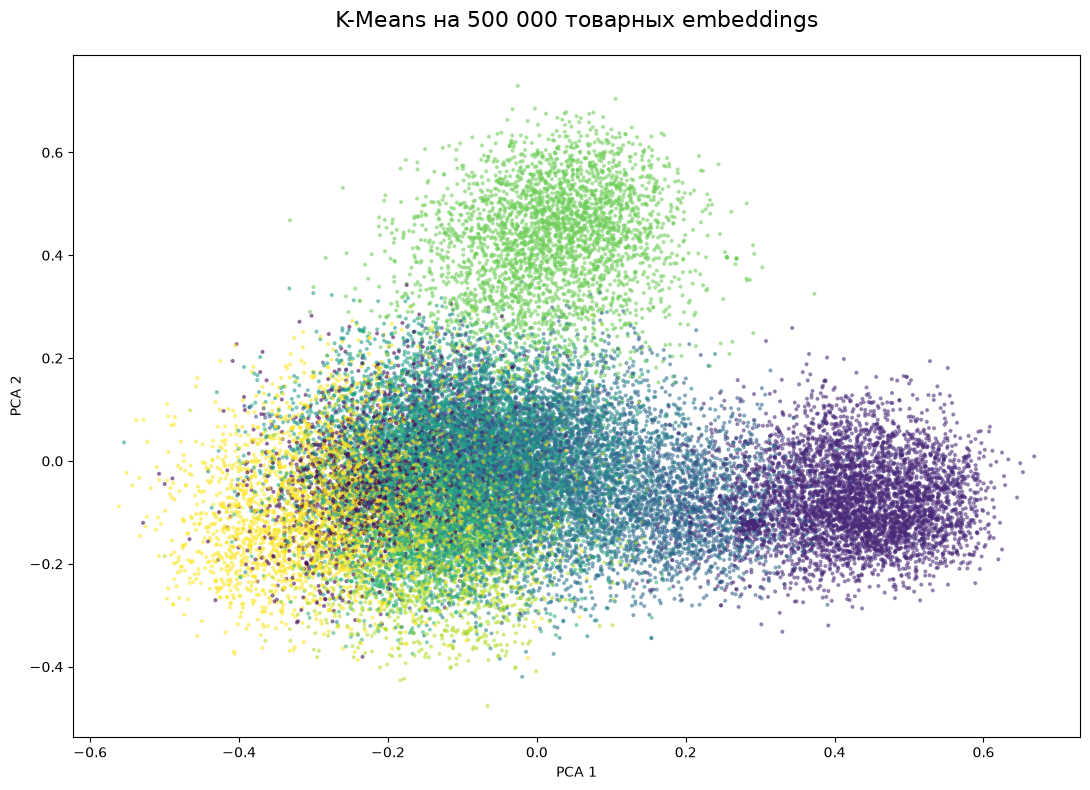

In [69]:
plt.figure(figsize=(11, 8))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_vis,
    s=4,
    alpha=0.45
)

plt.title(
    "K-Means на 500 000 товарных embeddings",
    fontsize=16,
    pad=20
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

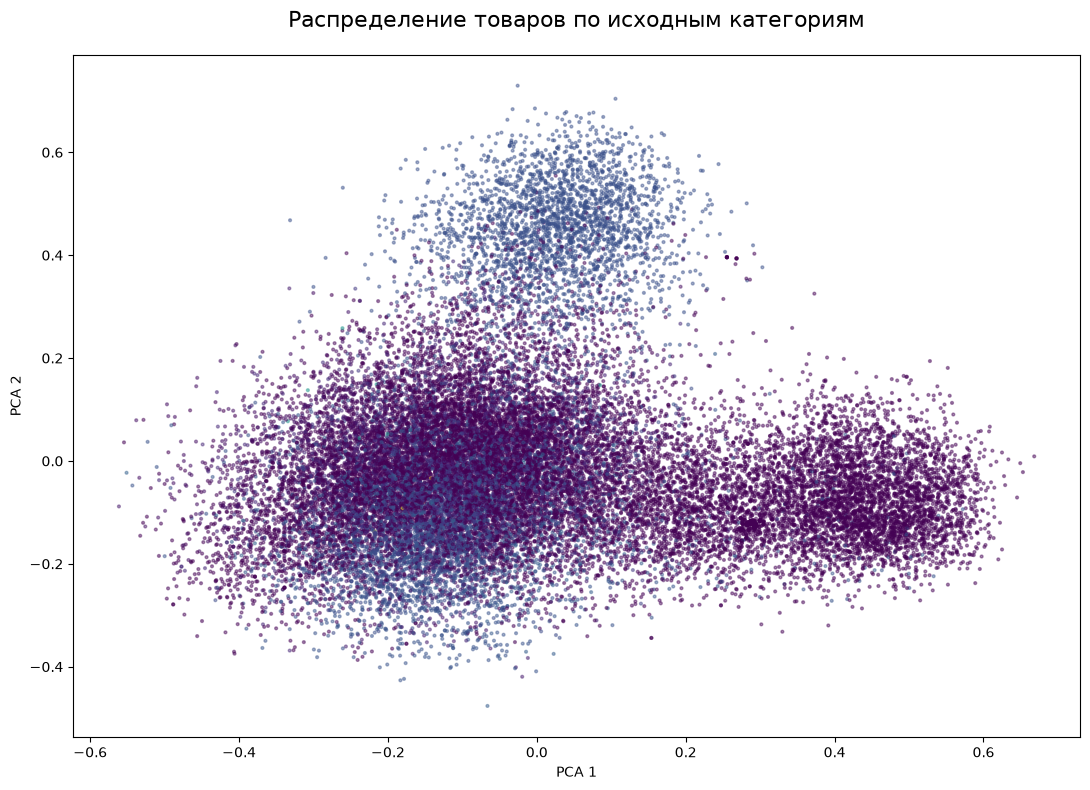

In [70]:
y_vis = y_large[vis_idx]

plt.figure(figsize=(11, 8))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_vis,
    s=4,
    alpha=0.45
)

plt.title(
    "Распределение товаров по исходным категориям",
    fontsize=16,
    pad=20
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

In [71]:
METRIC_SIZE = 100_000

rng = np.random.default_rng(RANDOM_STATE)

metric_idx = rng.choice(
    len(X_large),
    size=METRIC_SIZE,
    replace=False
)

X_metric = X_large[metric_idx]
y_metric = y_large[metric_idx]
labels_metric = labels_large[metric_idx]

silhouette_large = silhouette_score(
    X_metric,
    labels_metric
)

ari_large = adjusted_rand_score(
    y_metric,
    labels_metric
)

nmi_large = normalized_mutual_info_score(
    y_metric,
    labels_metric
)

print("Метрики на выборке 100k:")
print(f"Silhouette: {silhouette_large:.6f}")
print(f"ARI:        {ari_large:.6f}")
print(f"NMI:        {nmi_large:.6f}")

Метрики на выборке 100k:
Silhouette: 0.051119
ARI:        0.429411
NMI:        0.523438


In [72]:
VIS_SIZE = 100_000

rng = np.random.default_rng(RANDOM_STATE)

vis_idx = rng.choice(
    len(X_large),
    size=VIS_SIZE,
    replace=False
)

X_vis = X_large[vis_idx]
labels_vis = labels_large[vis_idx]

print("Визуализируем:", X_vis.shape)

# PCA только для визуализации
pca_vis = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_2d = pca_vis.fit_transform(X_vis)

print("После PCA:", X_2d.shape)
print(
    f"Объяснённая дисперсия: "
    f"{pca_vis.explained_variance_ratio_.sum():.2%}"
)

Визуализируем: (100000, 312)
После PCA: (100000, 2)
Объяснённая дисперсия: 9.39%


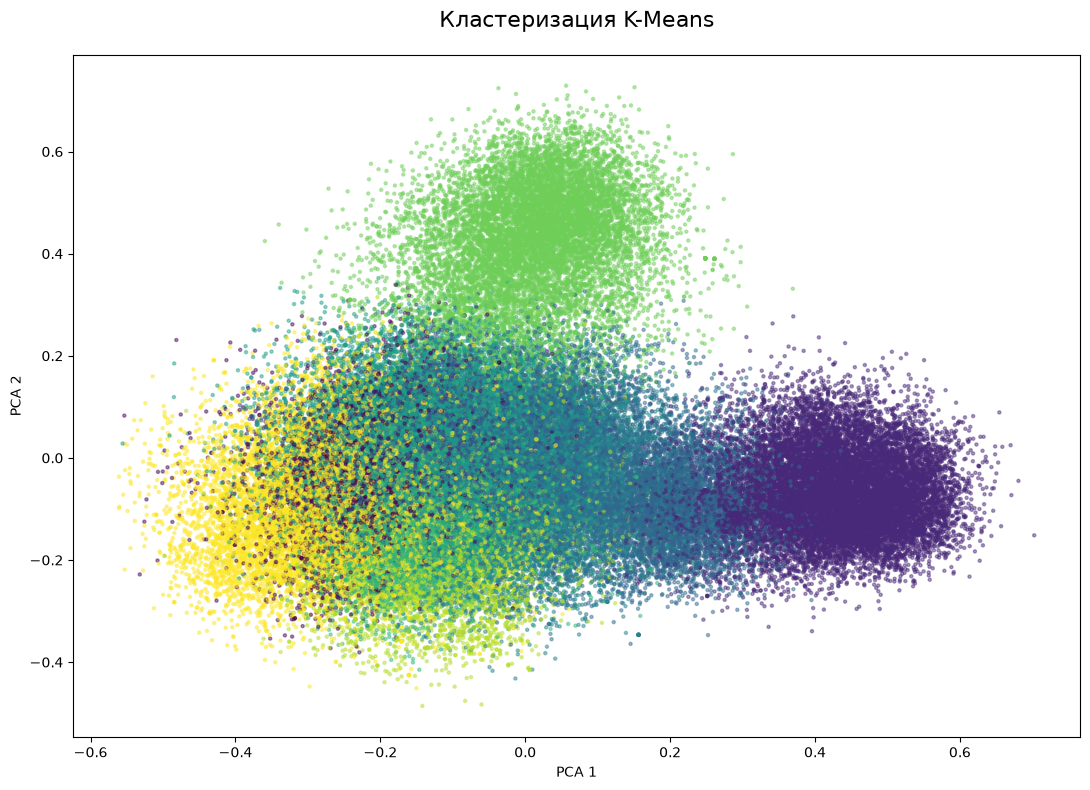

In [73]:
plt.figure(figsize=(11, 8))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_large[vis_idx],
    s=5,
    alpha=0.45
)

plt.title(
    "Кластеризация K-Means",
    fontsize=16,
    pad=20
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

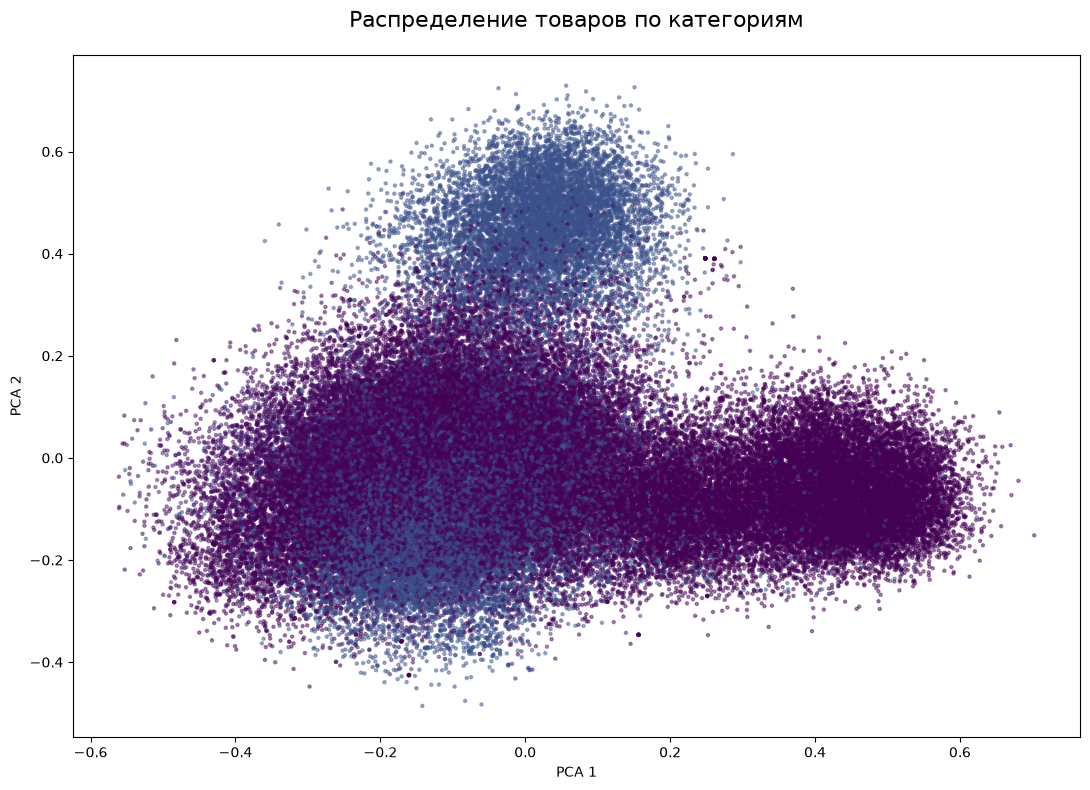

In [74]:
plt.figure(figsize=(11, 8))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_large[vis_idx],
    s=5,
    alpha=0.45
)

plt.title(
    "Распределение товаров по категориям",
    fontsize=16,
    pad=20
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

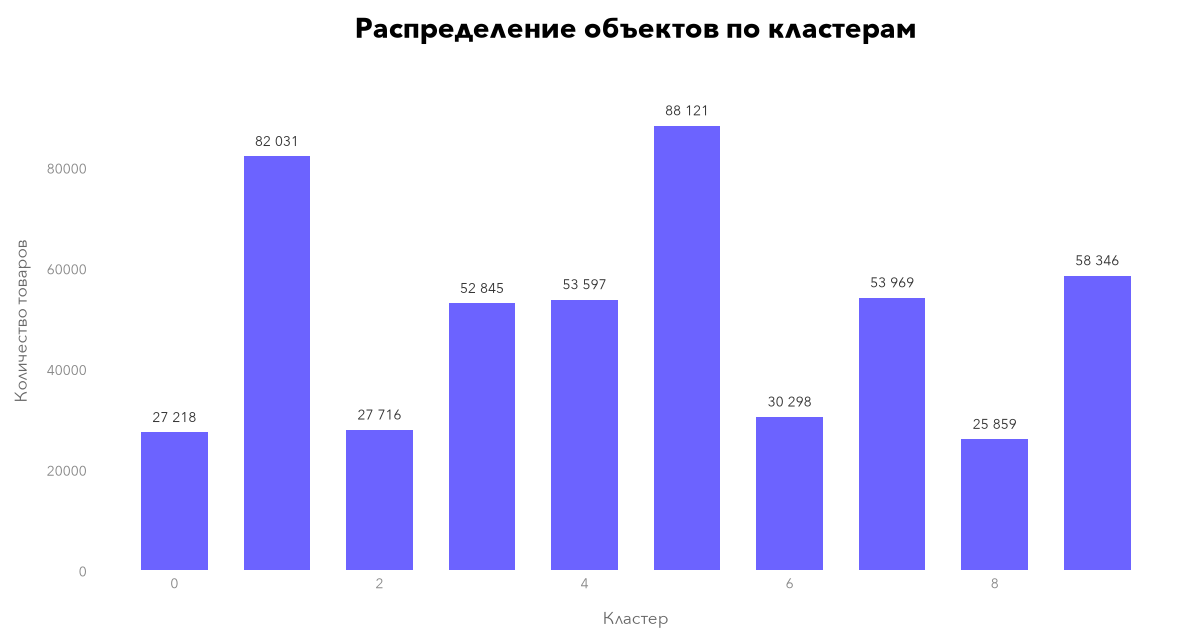

In [75]:
# Размеры кластеров K-Means

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Avenir Next"

cluster_sizes = np.bincount(labels_large)

fig, ax = plt.subplots(figsize=(12, 6.5))

bars = ax.bar(
    range(len(cluster_sizes)),
    cluster_sizes,
    width=0.65,
    color="#6C63FF"
)

# Заголовок
ax.set_title(
    "Распределение объектов по кластерам",
    fontsize=20,
    fontweight="bold",
    pad=25
)

# Подписи осей
ax.set_xlabel(
    "Кластер",
    fontsize=12,
    color="#666666",
    labelpad=10
)

ax.set_ylabel(
    "Количество товаров",
    fontsize=12,
    color="#666666",
    labelpad=10
)

# Убираем лишние элементы
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
    colors="#888888"
)

# Значения над столбцами
for bar, value in zip(bars, cluster_sizes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + cluster_sizes.max() * 0.012,
        f"{value:,}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=10,
        color="#333333"
    )

# Немного воздуха сверху
ax.set_ylim(
    0,
    cluster_sizes.max() * 1.12
)

plt.tight_layout()
plt.show()

In [76]:
import pandas as pd
from IPython.display import display

results_k_df = pd.DataFrame(results_k).copy()

# Форматирование для презентации
display_df = results_k_df.copy()

display_df["K"] = display_df["K"].astype(int)

for col in ["Silhouette", "ARI", "NMI"]:
    display_df[col] = display_df[col].map(lambda x: f"{x:.4f}")

display_df["Time_min"] = display_df["Time_min"].map(
    lambda x: f"{x:.2f}"
)

display_df.columns = [
    "Количество кластеров",
    "Silhouette",
    "ARI",
    "NMI",
    "Время, мин"
]

# Вывод
print("K-Means на 500 000 товарных embeddings")
print("─" * 70)

display(
    display_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "font-size": "13px",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#6C63FF"),
                ("color", "white"),
                ("font-weight", "600"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border-bottom", "1px solid #EEEEEE")
            ]
        }
    ])
)

NameError: name 'results_k' is not defined

In [ ]:
best_ari = results_k_df.loc[
    results_k_df["ARI"].idxmax()
]

best_nmi = results_k_df.loc[
    results_k_df["NMI"].idxmax()
]

best_silhouette = results_k_df.loc[
    results_k_df["Silhouette"].idxmax()
]

print("\n" + "─" * 70)
print("ИТОГ")
print("─" * 70)

print(
    f"Лучший ARI:        K = {int(best_ari['K'])} "
    f"→ {best_ari['ARI']:.4f}"
)

print(
    f"Лучший NMI:        K = {int(best_nmi['K'])} "
    f"→ {best_nmi['NMI']:.4f}"
)

print(
    f"Лучший Silhouette: K = {int(best_silhouette['K'])} "
    f"→ {best_silhouette['Silhouette']:.4f}"
)


──────────────────────────────────────────────────────────────────────
ИТОГ
──────────────────────────────────────────────────────────────────────
Лучший ARI:        K = 15 → 0.3697
Лучший NMI:        K = 50 → 0.5535
Лучший Silhouette: K = 5 → 0.0445


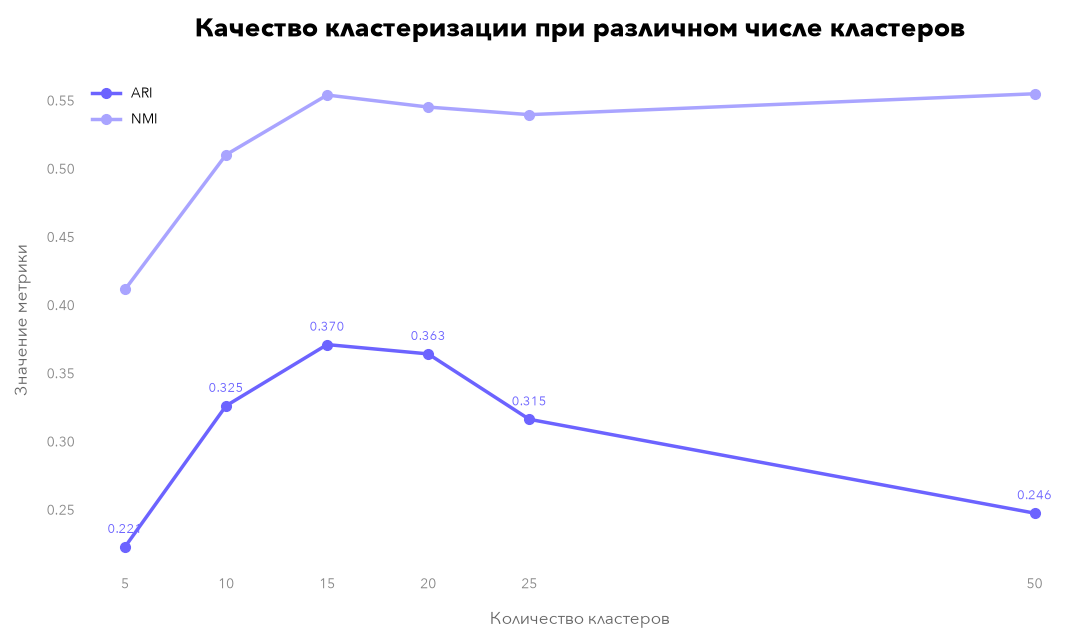

In [ ]:
plt.rcParams["font.family"] = "Avenir Next"

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.plot(
    results_k_df["K"],
    results_k_df["ARI"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#6C63FF",
    label="ARI"
)

ax.plot(
    results_k_df["K"],
    results_k_df["NMI"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#A9A4FF",
    label="NMI"
)

ax.set_title(
    "Качество кластеризации при различном числе кластеров",
    fontsize=19,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Количество кластеров",
    fontsize=12,
    color="#666666",
    labelpad=10
)

ax.set_ylabel(
    "Значение метрики",
    fontsize=12,
    color="#666666",
    labelpad=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
    colors="#888888"
)

ax.legend(
    frameon=False,
    loc="best"
)

# Значения непосредственно возле точек
for _, row in results_k_df.iterrows():

    ax.annotate(
        f"{row['ARI']:.3f}",
        (row["K"], row["ARI"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="#6C63FF"
    )

ax.set_xticks(results_k_df["K"])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
import numpy as np
import pandas as pd

# Матрица: строки = реальные категории, столбцы = кластеры
cm = contingency_matrix(y_large, labels_large)

# Для каждого кластера доля самой многочисленной категории
cluster_purity = cm.max(axis=0) / cm.sum(axis=0)

# Размеры кластеров
cluster_sizes = np.bincount(labels_large)

# Общая weighted purity
weighted_purity = cm.max(axis=0).sum() / cm.sum()

purity_df = pd.DataFrame({
    "cluster": np.arange(len(cluster_sizes)),
    "size": cluster_sizes,
    "purity": cluster_purity
})

print(f"Weighted purity: {weighted_purity:.6f}")

display(
    purity_df.style
    .hide(axis="index")
    .format({
        "cluster": "{:.0f}",
        "size": "{:,}",
        "purity": "{:.4f}"
    })
)

Weighted purity: 0.489698


cluster,size,purity
0,"27,218",0.5644
1,"82,031",0.9621
2,"27,716",0.4277
3,"52,845",0.4647
4,"53,597",0.0864
5,"88,121",0.1442
6,"30,298",0.5129
7,"53,969",0.8225
8,"25,859",0.5966
9,"58,346",0.3677


In [ ]:
category_values = np.sort(np.unique(y_large))

cluster_info = []

for cluster_id in range(len(cluster_sizes)):
    cluster_mask = labels_large == cluster_id
    categories_in_cluster = y_large[cluster_mask]

    counts = pd.Series(categories_in_cluster).value_counts()

    top_category = counts.index[0]
    top_count = counts.iloc[0]

    cluster_info.append({
        "cluster": cluster_id,
        "size": cluster_sizes[cluster_id],
        "top_category": top_category,
        "top_category_count": top_count,
        "purity": top_count / cluster_sizes[cluster_id],
        "num_categories": len(counts)
    })

cluster_info_df = pd.DataFrame(cluster_info)

display(
    cluster_info_df.style
    .hide(axis="index")
    .format({
        "size": "{:,}",
        "top_category_count": "{:,}",
        "purity": "{:.4f}",
        "num_categories": "{:.0f}"
    })
)

cluster,size,top_category,top_category_count,purity,num_categories
0,"27,218",91503,"15,362",0.5644,99
1,"82,031",91072,"78,919",0.9621,62
2,"27,716",90626,"11,855",0.4277,91
3,"52,845",91072,"24,559",0.4647,103
4,"53,597",4976530,"4,629",0.0864,117
5,"88,121",91499,"12,709",0.1442,121
6,"30,298",13939151,"15,541",0.5129,72
7,"53,969",14960839,"44,392",0.8225,88
8,"25,859",15876896,"15,428",0.5966,96
9,"58,346",90555,"21,455",0.3677,102


показывает, что одной ARI/NMI недостаточно

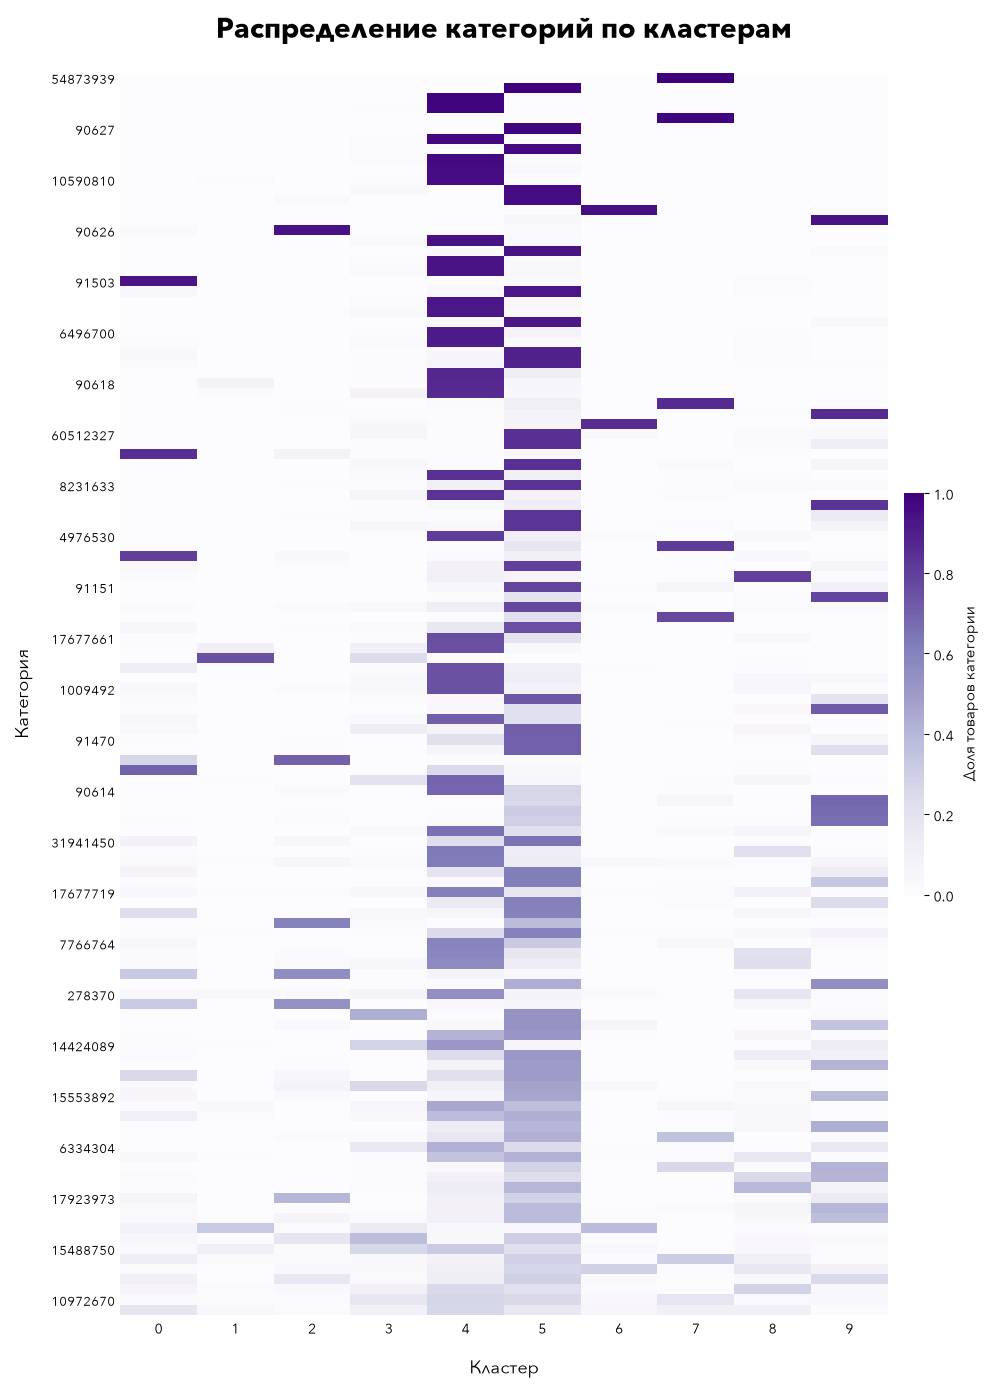

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Доли кластеров внутри каждой категории
heatmap_data = pd.crosstab(
    y_large,
    labels_large,
    normalize="index"
)

# Сортируем категории по кластеру,
# в который чаще всего попадают их товары
heatmap_data = heatmap_data.loc[
    heatmap_data.max(axis=1).sort_values(ascending=False).index
]

plt.rcParams["font.family"] = "Avenir Next"

fig, ax = plt.subplots(figsize=(10, 14))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Purples",
    vmin=0,
    vmax=1
)

ax.set_title(
    "Распределение категорий по кластерам",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel("Кластер", fontsize=13, labelpad=12)
ax.set_ylabel("Категория", fontsize=13, labelpad=12)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

# Чтобы не писать все 122 category_id
yticks = np.arange(0, len(heatmap_data), 5)
ax.set_yticks(yticks)
ax.set_yticklabels(
    heatmap_data.index[yticks],
    fontsize=9
)

ax.tick_params(
    axis="both",
    length=0
)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Доля товаров категории", fontsize=11)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Берём только нужные столбцы из исходной выборки
cluster_samples = category_data.loc[
    category_data.index.isin(sample_indices_large),
    ["model_text", "category_id"]
].copy()

# Важно: привести порядок к sample_indices_large
cluster_samples = cluster_samples.loc[sample_indices_large]

cluster_samples["cluster"] = labels_large

cluster_samples.head()

KeyError: "['model_text'] not in index"

In [ ]:
import pyarrow.parquet as pq
import numpy as np
import pandas as pd

parquet_file = pq.ParquetFile(DATA_PATH)

texts_large = np.empty(len(sample_indices_large), dtype=object)

current_position = 0
sample_position = 0

for batch in parquet_file.iter_batches(
    columns=["model_text"],
    batch_size=10_000
):
    batch_size = len(batch["model_text"])

    batch_start = current_position
    batch_end = current_position + batch_size

    left = np.searchsorted(
        sample_indices_large,
        batch_start,
        side="left"
    )
    right = np.searchsorted(
        sample_indices_large,
        batch_end,
        side="left"
    )

    if left < right:
        local_indices = (
            sample_indices_large[left:right] - batch_start
        )

        for pos in local_indices:
            value = batch["model_text"][pos].as_py()

            if isinstance(value, bytes):
                value = value.decode("utf-8", errors="replace")

            texts_large[sample_position] = value
            sample_position += 1

    current_position = batch_end

    if current_position % 500_000 == 0:
        print(f"Обработано: {current_position:,}")

print("Готово!")
print("texts_large:", texts_large.shape)

Обработано: 500,000
Обработано: 1,000,000
Обработано: 1,500,000
Обработано: 2,000,000
Обработано: 2,500,000
Обработано: 3,000,000
Обработано: 3,500,000
Обработано: 4,000,000
Обработано: 4,500,000
Готово!
texts_large: (500000,)


In [ ]:
cluster_samples = pd.DataFrame({
    "model_text": texts_large,
    "category_id": y_large,
    "cluster": labels_large
})

print(cluster_samples.shape)
display(cluster_samples.head())

(500000, 3)


,model_text,category_id,cluster
0,Дисплей для OPPO Reno 13 F 4G In-Cell ЧерныйНе...,91499,5
1,Дисплей для Samsung Galaxy A56 5G Черный In-Ce...,91499,3
2,Дисплей для Xiaomi Redmi Note 14 4G OLEDНе опр...,91499,5
3,Защитный экран Скрин Мобайл для ZTE Blade V8 L...,91072,3
4,Защитный экран Скрин Мобайл для Blackview Osca...,91072,3


In [ ]:
# Расстояние каждого товара до центра своего кластера
distances = np.linalg.norm(
    X_large - kmeans.cluster_centers_[labels_large],
    axis=1
)

cluster_samples["distance_to_center"] = distances

N_EXAMPLES = 10

for cluster_id in range(10):

    cluster_data = (
        cluster_samples[
            cluster_samples["cluster"] == cluster_id
        ]
        .sort_values("distance_to_center")
        .head(N_EXAMPLES)
    )

    print("\n" + "=" * 100)
    print(f"КЛАСТЕР {cluster_id}")
    print("=" * 100)

    for i, (_, row) in enumerate(cluster_data.iterrows(), 1):

        text = str(row["model_text"]).replace("\n", " ")

        if len(text) > 400:
            text = text[:400] + "..."

        print(
            f"\n{i}. "
            f"category={row['category_id']} | "
            f"distance={row['distance_to_center']:.4f}"
        )

        print(text)

IndexError: index 5 is out of bounds for axis 0 with size 5

In [ ]:
kmeans_large = KMeans(
    n_clusters=10,
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=300
)

labels_large_check = kmeans_large.fit_predict(X_large)

print("labels_large:", labels_large.shape)
print("labels_large_check:", labels_large_check.shape)

print(
    "Совпадает ли кластеризация:",
    np.mean(labels_large == labels_large_check)
)

labels_large: (500000,)
labels_large_check: (500000,)
Совпадает ли кластеризация: 0.166482


In [ ]:
print(
    "ARI:",
    adjusted_rand_score(y_large, labels_large_check)
)

print(
    "NMI:",
    normalized_mutual_info_score(y_large, labels_large_check)
)

ARI: 0.32718824229945
NMI: 0.5042728092529829


In [ ]:
[name for name, obj in globals().items()
 if isinstance(obj, KMeans)]

['kmeans', 'kmeans_raw', 'kmeans_l2', 'kmeans_large']

In [ ]:
for name in ["kmeans", "kmeans_raw", "kmeans_l2", "kmeans_large"]:
    model = globals()[name]
    
    print(
        f"{name}: "
        f"K={model.n_clusters}, "
        f"centers={model.cluster_centers_.shape}"
    )

kmeans: K=5, centers=(5, 312)
kmeans_raw: K=10, centers=(10, 312)
kmeans_l2: K=10, centers=(10, 312)
kmeans_large: K=10, centers=(10, 312)


In [ ]:
for name in ["kmeans", "kmeans_raw", "kmeans_l2", "kmeans_large"]:
    model = globals()[name]
    
    if model.n_clusters == 10:
        try:
            distances = np.linalg.norm(
                X_large - model.cluster_centers_[labels_large],
                axis=1
            )
            
            print(
                f"{name}: среднее расстояние = "
                f"{distances.mean():.6f}"
            )
        except Exception as e:
            print(f"{name}: ошибка — {e}")

kmeans_raw: среднее расстояние = 1.011889
kmeans_l2: среднее расстояние = 1.047735
kmeans_large: среднее расстояние = 1.006843


In [ ]:
from sklearn.metrics import adjusted_rand_score

for name in ["kmeans", "kmeans_raw", "kmeans_l2", "kmeans_large"]:
    model = globals()[name]
    
    if model.n_clusters == 10:
        predicted = model.predict(X_large)
        score = adjusted_rand_score(labels_large, predicted)
        
        print(f"{name}: ARI with labels_large = {score:.6f}")

kmeans_raw: ARI with labels_large = 0.788930
kmeans_l2: ARI with labels_large = 0.685054
kmeans_large: ARI with labels_large = 0.864015


In [ ]:
cluster_samples["cluster"] = labels_large

In [ ]:
N_EXAMPLES = 10

for cluster_id in range(10):

    cluster_data = cluster_samples[
        cluster_samples["cluster"] == cluster_id
    ]

    examples = cluster_data.sample(
        n=min(N_EXAMPLES, len(cluster_data)),
        random_state=RANDOM_STATE
    )

    print("\n" + "=" * 100)
    print(f"КЛАСТЕР {cluster_id} | товаров: {len(cluster_data):,}")
    print("=" * 100)

    for i, (_, row) in enumerate(examples.iterrows(), 1):

        text = str(row["model_text"]).replace("\n", " ")

        if len(text) > 400:
            text = text[:400] + "..."

        print(
            f"\n{i}. "
            f"category={row['category_id']}"
        )
        print(text)


КЛАСТЕР 0 | товаров: 27,218

1. category=91503
Зарядное устройство 'BA46A' 18W+QC3.0, 2 порта Type-C+USB, черныйНе определен<h3>Быстрая и безопасная зарядка для ваших устройств</h3><p>Современное зарядное устройство &#39;BA46A&#39; обеспечивает максимально быструю и стабильную зарядку благодаря поддержке технологий PD18W и QC3.0. Высокая мощность 18 Вт позволяет заряжать устройства всего за несколько часов, экономя ваше время.</p><h3>Универсал...

2. category=186461
Зарядная док-станция Switch OLED 6-в-1 черныйHUKAIФункции:<br /><br />совершенно новый и качественный<br /><br />Док-станция для зарядки геймпада 6 в 1: эта док-станция для зарядки геймпада способна одновременно заряжать 6 игровых контроллеров, а именно 2 больших геймпада и 4 маленьких.<br /><br />Быстрая зарядка: выходной ток 750 мА для одного геймпада позволяет быстро заряжать вашу игру.<br /><b...

3. category=91503
Блок питания 12V - 2A для настольной лампы Mi Smart LED Desk Lamp 1S с разъемом 4.0x1.7, шнур 1.9 мOemС б

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import numpy as np
import pandas as pd

METRIC_SIZE = 100_000

rng = np.random.default_rng(RANDOM_STATE)
metric_idx = rng.choice(len(X_large), METRIC_SIZE, replace=False)

y_metric = y_large[metric_idx]

labels_raw = kmeans_raw.labels_

results_methods = []

results_methods.append({
    "Method": "Raw",
    "Silhouette": silhouette_score(
        X_large[metric_idx],
        labels_raw[metric_idx]
    ),
    "ARI": adjusted_rand_score(
        y_metric,
        labels_raw[metric_idx]
    ),
    "NMI": normalized_mutual_info_score(
        y_metric,
        labels_raw[metric_idx]
    )
})

X_large_l2 = normalize(X_large, norm="l2")

labels_l2 = kmeans_l2.labels_

results_methods.append({
    "Method": "L2",
    "Silhouette": silhouette_score(
        X_large_l2[metric_idx],
        labels_l2[metric_idx]
    ),
    "ARI": adjusted_rand_score(
        y_metric,
        labels_l2[metric_idx]
    ),
    "NMI": normalized_mutual_info_score(
        y_metric,
        labels_l2[metric_idx]
    )
})

results_methods_df = pd.DataFrame(results_methods)

display(
    results_methods_df.style
    .hide(axis="index")
    .format({
        "Silhouette": "{:.6f}",
        "ARI": "{:.6f}",
        "NMI": "{:.6f}"
    })
)

IndexError: index 352879 is out of bounds for axis 0 with size 100000

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

METRIC_SIZE = 100_000

rng = np.random.default_rng(RANDOM_STATE)
metric_idx = rng.choice(len(X_large), METRIC_SIZE, replace=False)

X_metric = X_large[metric_idx]
y_metric = y_large[metric_idx]

kmeans_raw_large = KMeans(
    n_clusters=10,
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=300
)

labels_raw_large = kmeans_raw_large.fit_predict(X_large)

X_large_l2 = normalize(X_large)

kmeans_l2_large = KMeans(
    n_clusters=10,
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=300
)

labels_l2_large = kmeans_l2_large.fit_predict(X_large_l2)

results_methods = pd.DataFrame([
    {
        "Method": "Raw",
        "Silhouette": silhouette_score(
            X_metric,
            labels_raw_large[metric_idx]
        ),
        "ARI": adjusted_rand_score(
            y_metric,
            labels_raw_large[metric_idx]
        ),
        "NMI": normalized_mutual_info_score(
            y_metric,
            labels_raw_large[metric_idx]
        )
    },
    {
        "Method": "L2",
        "Silhouette": silhouette_score(
            X_large_l2[metric_idx],
            labels_l2_large[metric_idx]
        ),
        "ARI": adjusted_rand_score(
            y_metric,
            labels_l2_large[metric_idx]
        ),
        "NMI": normalized_mutual_info_score(
            y_metric,
            labels_l2_large[metric_idx]
        )
    }
])

display(
    results_methods.style
    .hide(axis="index")
    .format({
        "Silhouette": "{:.6f}",
        "ARI": "{:.6f}",
        "NMI": "{:.6f}"
    })
)

Method,Silhouette,ARI,NMI
Raw,0.037892,0.326061,0.504672
L2,0.049465,0.434004,0.532102


для наших эмбеддингов направление вектора важнее его абсолютной нормы, и L2-нормализация перед K-Means помогает.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

pca = PCA(
    n_components=256,
    random_state=RANDOM_STATE
)

X_pca_large = pca.fit_transform(X_large)

X_pca_l2_large = normalize(X_pca_large)

kmeans_pca_l2 = KMeans(
    n_clusters=10,
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=300
)

labels_pca_l2 = kmeans_pca_l2.fit_predict(X_pca_l2_large)

results_pca_l2 = {
    "Method": "PCA + L2",
    "Silhouette": silhouette_score(
        X_pca_l2_large[metric_idx],
        labels_pca_l2[metric_idx]
    ),
    "ARI": adjusted_rand_score(
        y_metric,
        labels_pca_l2[metric_idx]
    ),
    "NMI": normalized_mutual_info_score(
        y_metric,
        labels_pca_l2[metric_idx]
    )
}

print(results_pca_l2)

NameError: name 'X_large' is not defined